<a href="https://colab.research.google.com/github/Shusnigdha/demand-forecasting/blob/main/demand_forecasting_preproccessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/demand_forecasting.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
df.dtypes

,0
Date,object
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df.isna().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekDay"] = df["Date"].dt.day_name()
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [ ]:
df["Discounted Price"] = df["Price"] * (1 - df["Discount"] / 100)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.410


In [ ]:
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"]
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [ ]:
df.groupby("Category")["Demand"].agg(["mean", "sum"]).sort_values(by = "sum", ascending= False).reset_index()

,Category,mean,sum
0,Groceries,120.976447,3677684
1,Clothing,112.619737,1369456
2,Furniture,73.581140,1006590
3,Toys,92.606955,985338
4,Electronics,97.482018,889036


In [ ]:
df.groupby(["Region", "Seasonality"])["Demand"].mean().reset_index()

,Region,Seasonality,Demand
0,East,Autumn,106.353297
1,East,Spring,100.168478
2,East,Summer,115.388315
3,East,Winter,104.273571
4,North,Autumn,103.065797
5,North,Spring,97.399457
6,North,Summer,112.843750
7,North,Winter,102.017738
8,South,Autumn,104.464560
9,South,Spring,100.328804


In [ ]:
pd.pivot_table(df, values = "Demand", index = "Month", columns = "Category", aggfunc = "mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


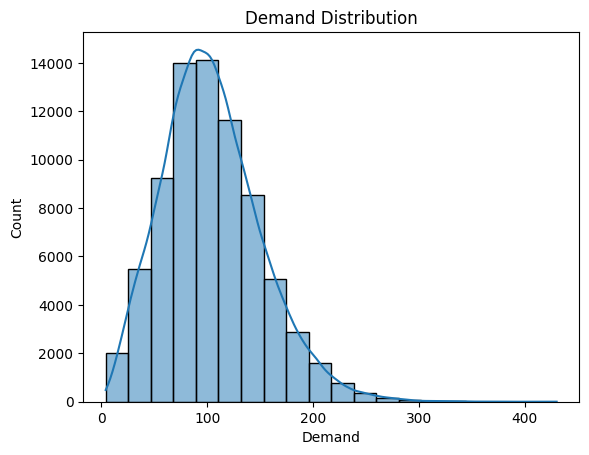

In [ ]:
sns.histplot(df["Demand"], bins = 20, kde = True)
plt.title("Demand Distribution")
plt.show()

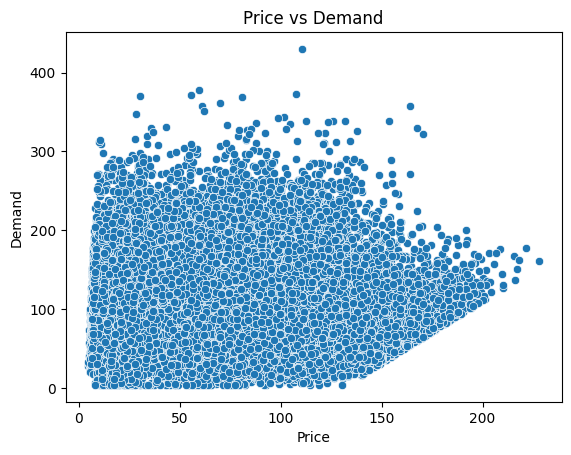

In [ ]:
sns.scatterplot(x = "Price", y = "Demand", data = df)
plt.title("Price vs Demand")
plt.show()

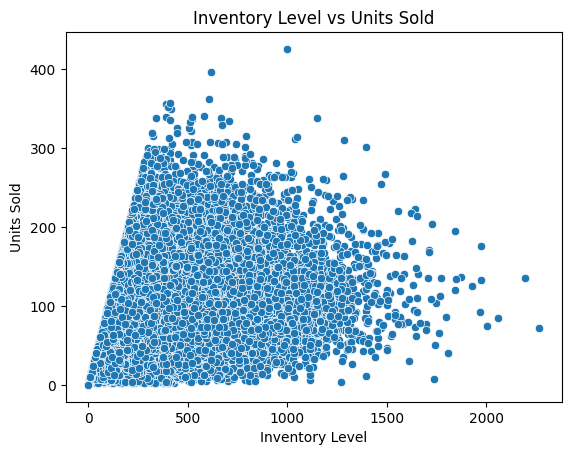

In [ ]:
sns.scatterplot(x = "Inventory Level", y = "Units Sold", data = df)
plt.title("Inventory Level vs Units Sold")
plt.show()

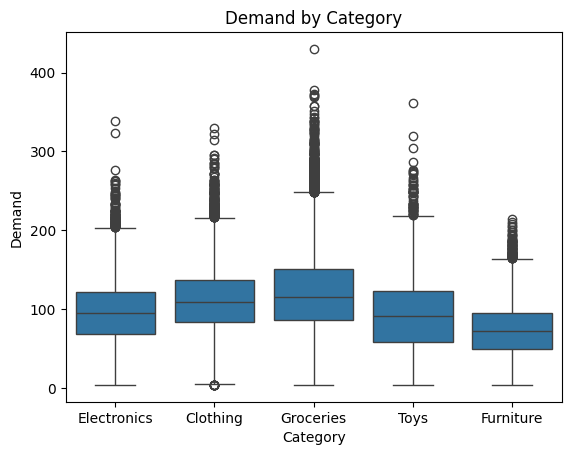

In [ ]:
sns.boxplot(x = "Category", y = "Demand", data = df)
plt.title("Demand by Category")
plt.show()

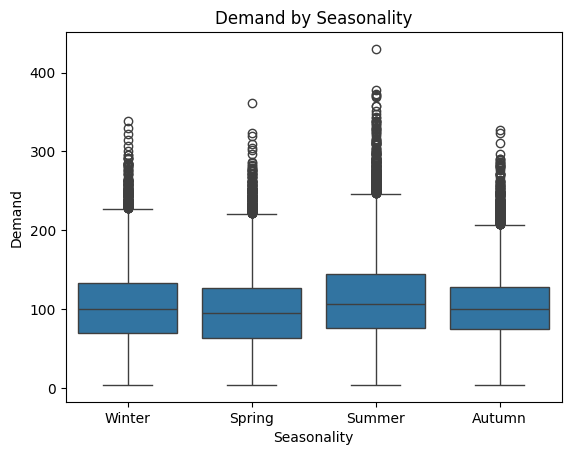

In [ ]:
sns.boxplot(x = "Seasonality", y = "Demand", data = df)
plt.title("Demand by Seasonality")
plt.show()

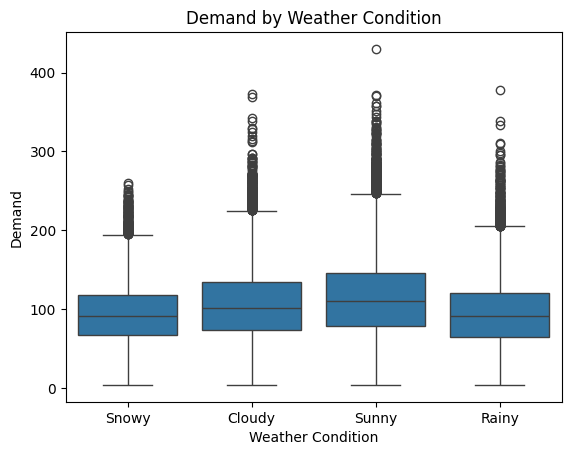

In [ ]:
sns.boxplot(x = "Weather Condition", y = "Demand", data = df)
plt.title("Demand by Weather Condition")
plt.show()

In [ ]:
monthly_demand = df.groupby("Month")["Demand"].mean()
monthly_demand

,Demand
Month,
1,106.040000
2,92.882500
3,113.613871
4,92.816667
5,86.521129
6,117.346000
7,101.561613
8,119.803387
9,107.431500


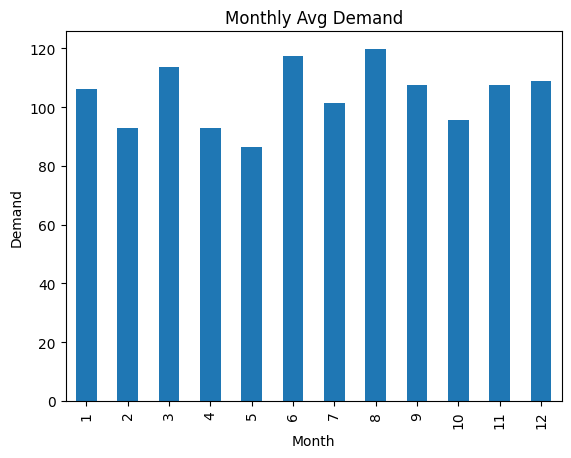

In [ ]:
monthly_demand.plot(kind = "bar")
plt.title("Monthly Avg Demand")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.show()

In [ ]:
daily_demand = df.groupby("Date")["Demand"].sum()
daily_demand

,Demand
Date,
2022-01-01,10060
2022-01-02,10814
2022-01-03,11317
2022-01-04,11469
2022-01-05,11724
...,...
2024-01-26,11182
2024-01-27,11540
2024-01-28,11440


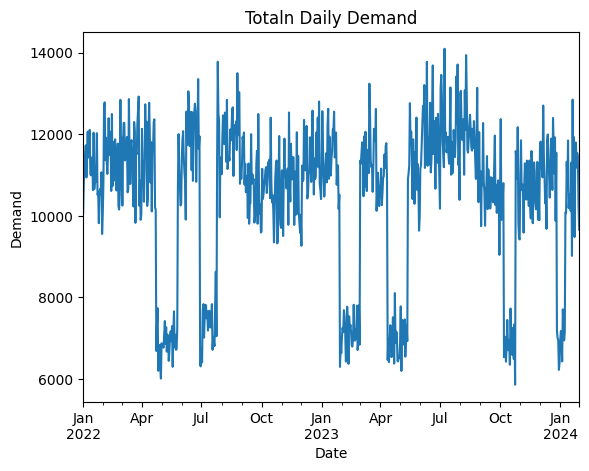

In [ ]:
daily_demand.plot()
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

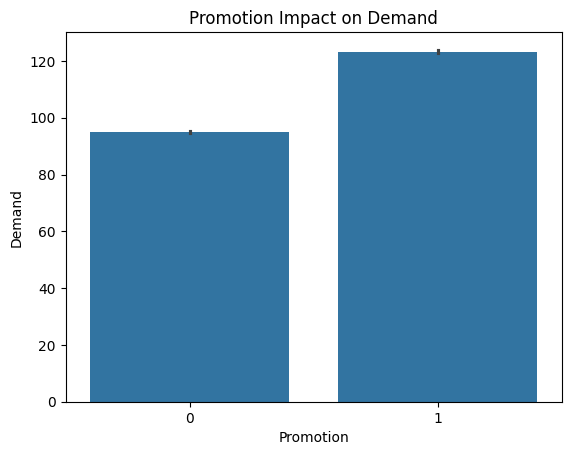

In [ ]:
sns.barplot(x = "Promotion", y = "Demand", data = df)
plt.title("Promotion Impact on Demand")
plt.show()

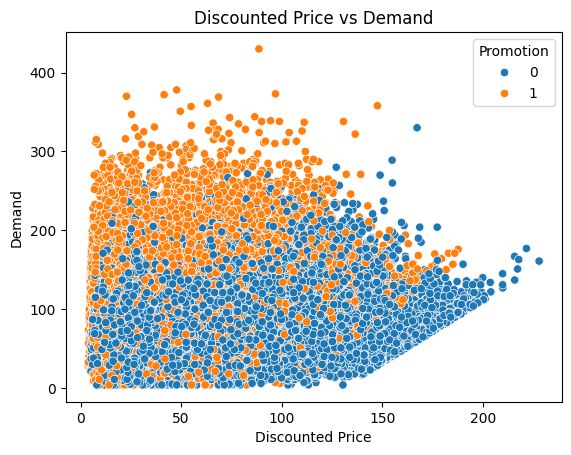

In [ ]:
sns.scatterplot(x = "Discounted Price", y = "Demand", hue = "Promotion", data = df)
plt.title("Discounted Price vs Demand")
plt.show()

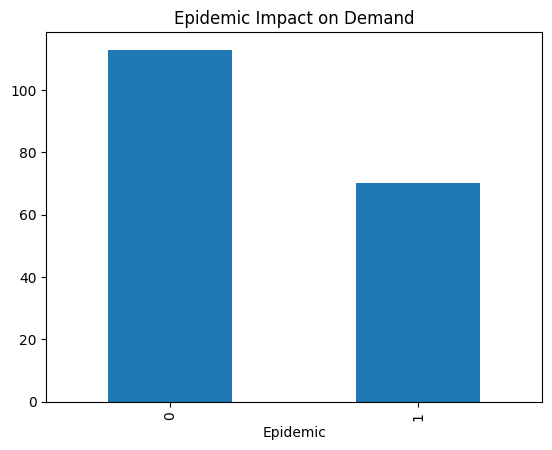

In [ ]:
df.groupby("Epidemic")["Demand"].mean().plot(kind = "bar", title= "Epidemic Impact on Demand")
plt.show()

In [ ]:
df.to_csv("demand_forecasting_preprocessed.csv")